# Few-Shot with a SimpleShot
Creates a model that combines pybioclip image embeddings with [SimpleShot](https://arxiv.org/abs/1911.04623) using images from the [Somnath01/Birds_Species](https://huggingface.co/datasets/Somnath01/Birds_Species) dataset. This dataset contains 1000 train images, 403 test images, and 50 validation images. This notebook only uses the train and test images. This dataset was chosen for convenience. No analysis of the suitability of this dataset has been done.

When running this notebook in COLAB change the _runtime type_ to a GPU type to speed up processing. Additionally when running the next step in COLAB you you may see an error about the version of `fsspec` installed. This issue doesn't seem to cause any problem with this notebook.

In [1]:
!pip install -q numpy datasets pybioclip scikit-learn matplotlib

In [1]:
import itertools
import numpy as np
from tqdm.notebook import tqdm

import torch
from datasets import load_dataset

from bioclip.predict import BaseClassifier

import sklearn.neighbors

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:
# Dataset settings
HF_DATASET_NAME = "Somnath01/Birds_Species"
TRAIN_NAME = 'train'
TEST_NAME = 'test'
IMAGE_NAME = 'image'
LABEL_NAME = 'label'

# Image embedding settings
BATCH_SIZE = 30

## Determine GPU or CPU

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


## Load dataset
This step takes around 7 minutes to download the images the first time it is run.

### Setting up HF_TOKEN (Recommended for Google Colab)

You may see warnings `The secret 'HF_TOKEN' does not exist in your Colab secrets.` when running the code block below. To avoid rate limiting errors when running in Google Colab, follow these steps to set up your HuggingFace token:

1. **Create a HuggingFace account and token:**
   - Go to [https://huggingface.co/](https://huggingface.co/) and create an account if you don't have one
   - Navigate to your [Access Tokens page](https://huggingface.co/settings/tokens)
   - Click "New token" and create a token with "Read" permissions
   - Copy the generated token

2. **Add the token as a Colab secret:**
   - In Google Colab, click the key icon (🔑) in the left sidebar to open the Secrets panel
   - Click "Add new secret"
   - Set the name to `HF_TOKEN`
   - Paste your HuggingFace token as the value
   - Click "Add secret"

3. **Grant notebook access to the secret:**
   - In the Secrets panel, find your `HF_TOKEN` secret
   - Toggle the switch next to the notebook name to grant access
   - The switch should turn blue/green when enabled

After setting up the token, restart your runtime (Runtime → Restart runtime) and re-run the cells above before proceeding.

In [4]:
dataset = load_dataset(HF_DATASET_NAME)
dataset

Resolving data files:   0%|          | 0/1000 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/50 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/403 [00:00<?, ?it/s]

train/ABBOTTS BABBLER/001.jpg:   0%|          | 0.00/25.1k [00:00<?, ?B/s]

train/ABBOTTS BABBLER/003.jpg:   0%|          | 0.00/26.6k [00:00<?, ?B/s]

...

test/ALBATROSS/5.jpg:   0%|          | 0.00/22.9k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/50 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/403 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 1000
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 50
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 403
    })
})

Labels: ABBOTTS BABBLER,ABBOTTS BOOBY,ABYSSINIAN GROUND HORNBILL,AFRICAN CROWNED CRANE,AFRICAN EMERALD CUCKOO,AFRICAN FIREFINCH,AFRICAN OYSTER CATCHER,AFRICAN PIED HORNBILL,AFRICAN PYGMY GOOSE,ALBATROSS 

Example Image: <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=224x224 at 0x13699B4A0>


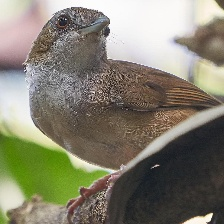

In [5]:
print("Labels:", ",".join(dataset[TRAIN_NAME].features[LABEL_NAME].names), "\n")
print("Example Image:", dataset[TRAIN_NAME][IMAGE_NAME][0])
dataset[TRAIN_NAME][IMAGE_NAME][0]

## Function to Convert PIL to image embeddings

In [6]:
classifier = BaseClassifier(device=device)

In [7]:
def batched(items, batch_size):
    it = iter(items)
    while (batch := list(itertools.islice(it, batch_size))):
          yield batch

In [8]:
def create_image_features(pil_image_ary):
    # batch PIL -> features transformation
    all_features = []
    with tqdm(total=len(pil_image_ary), desc='Creating image embeddings', unit='image') as progress_bar:
        for images in batched(pil_image_ary, BATCH_SIZE):
            features = classifier.create_image_features(images, normalize=True)
            all_features.append(features.cpu())
            progress_bar.update(len(images))
    return torch.cat(all_features, dim=0).cpu().numpy()

## Function to show prediction metrics

In [9]:
def show_metrics(expected_label_ary, predicted_label_ary):
    print("Accuracy:", round(accuracy_score(expected_label_ary, predicted_label_ary), 3))
    cm = confusion_matrix(expected_label_ary, predicted_label_ary)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    disp.ax_.set_title("Confusion Matrix")
    plt.show()

## SimpleShot
The next block of code is based on [biobench simpleshot](https://github.com/samuelstevens/biobench/blob/main/biobench/simpleshot.py) 
created by [@samuelstevens](https://github.com/samuelstevens).

In [10]:
def l2_normalize(features,):
    """L2-normalize a batch of features."""
    norms = np.linalg.norm(features, ord=2, axis=1, keepdims=True)
    return features / norms


class SimpleShot(object):
    def __init__(self, device):
        self.device = device
        self.x_mean = None
        self.centroids = None

    def mean_normalize(self, x):
        return l2_normalize(x - self.x_mean)
        
    def fit(self, pil_images, labels):
        x_train = create_image_features(pil_images)

        # Calculate mean for use in predict
        self.x_mean = x_train.mean(axis=0, keepdims=True)
        x_norm = self.mean_normalize(x_train)

        # Calculate centroids for use in predict
        clf = sklearn.neighbors.NearestCentroid()
        clf.fit(x_norm, labels)
        self.centroids = torch.from_numpy(clf.centroids_).type(torch.float32).to(device)

    def predict(self, pil_images):
        if self.x_mean is None:
            raise ValueError("You must call fit() before running predict().")
        x_test = create_image_features(pil_images)

        # normalize image features and move to device
        x_norm = self.mean_normalize(x_test)
        x_test = torch.from_numpy(x_test).to(device)

        # use closest centroid to determine label
        distances = torch.linalg.vector_norm(x_test[:, None] - self.centroids, axis=2)
        preds = torch.argmin(distances, dim=1)
        return preds.cpu().numpy()

## Train the model
Trains the SimpleShot using the train dataset. This step takes ~ 8 minutes when running on CPU and ~ 1 minute otherwise.

In [11]:
simpleshot = SimpleShot(device)
# Convert dataset columns to lists for Colab compatibility (sklearn requires list-like objects)
simpleshot.fit(list(dataset[TRAIN_NAME][IMAGE_NAME]), list(dataset[TRAIN_NAME][LABEL_NAME]))

Creating image embeddings:   0%|          | 0/1000 [00:00<?, ?image/s]

## Create predictions
Predicts species for the test dataset. This step takes ~ 5 minutes when running on CPU and ~1 minute otherwise.

Creating image embeddings:   0%|          | 0/403 [00:00<?, ?image/s]

Accuracy: 0.983


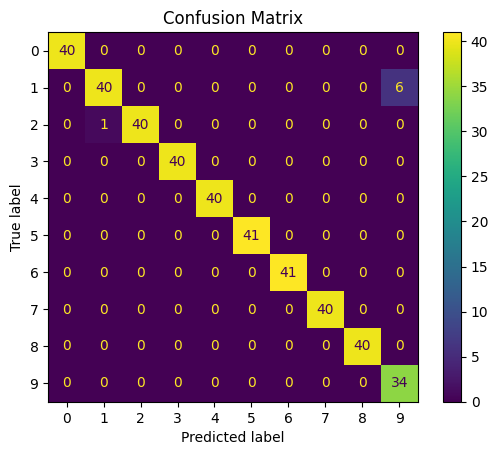

In [12]:
# Convert dataset columns to lists for Colab compatibility (sklearn requires list-like objects)
predicted_labels = simpleshot.predict(list(dataset[TEST_NAME][IMAGE_NAME]))
show_metrics(predicted_labels, list(dataset[TEST_NAME][LABEL_NAME]))

## Compare against direct zero-shot pybioclip predictions
This step takes ~ 6 minutes when running on CPU and ~1 minute otherwise.

100%|██████████| 13/13 [00:01<00:00,  9.46images/s]

Accuracy: 0.985


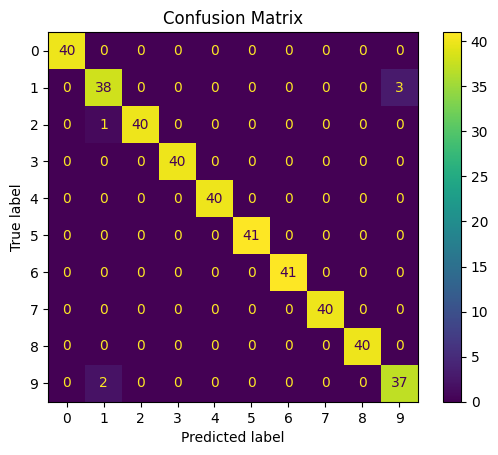

In [13]:
from bioclip.predict import CustomLabelsClassifier
classifier = CustomLabelsClassifier(dataset[TEST_NAME].features[LABEL_NAME].names, device=device)
predicted_labels = []
# Convert dataset columns to lists for Colab compatibility
for images in batched(list(dataset[TEST_NAME][IMAGE_NAME]), BATCH_SIZE):
    predictions = classifier.predict(images, k=1)
    for pred in predictions:
        label_str = pred['classification']
        label = dataset[TEST_NAME].features[LABEL_NAME].str2int(label_str)
        predicted_labels.append(label)
# Convert dataset columns to lists for Colab compatibility
show_metrics(predicted_labels, list(dataset[TEST_NAME][LABEL_NAME]))